In [1]:
from modules.dataclass import TSP

## 1. データ入力

In [2]:
tsp = TSP(file_name='burma14.tsp')
tsp.generate()

In [3]:
problem = tsp.problem
nodes = tsp.node
tsp.describe()

problem: Problem(file_name='burma14.tsp', edge_weight_type='GEO', dimension=14, correct_answer=[0, 9, 8, 10, 7, 12, 6, 11, 5, 4, 3, 2, 13, 1])
node: [Node(id=0, x_coord=16.47, y_coord=96.1), Node(id=1, x_coord=16.47, y_coord=94.44), Node(id=2, x_coord=20.09, y_coord=92.54), Node(id=3, x_coord=22.39, y_coord=93.37), Node(id=4, x_coord=25.23, y_coord=97.24), Node(id=5, x_coord=22.0, y_coord=96.05), Node(id=6, x_coord=20.47, y_coord=97.02), Node(id=7, x_coord=17.2, y_coord=96.29), Node(id=8, x_coord=16.3, y_coord=97.38), Node(id=9, x_coord=14.05, y_coord=98.12), Node(id=10, x_coord=16.53, y_coord=97.38), Node(id=11, x_coord=21.52, y_coord=95.59), Node(id=12, x_coord=19.41, y_coord=97.13), Node(id=13, x_coord=20.09, y_coord=94.55)]


## 2.前処理

In [4]:
from modules.pre_processing import Area

In [5]:
area = Area(problem=problem, nodes=nodes)
dist_matrix = area.get_dist_matrix()

## 3. 最適化

In [6]:
from modules.model_route import ModelRoute
model_route = ModelRoute(problem=problem, nodes=nodes, dist_matrix=dist_matrix)
model_route.to_optimize()
route = model_route.route

## 4. 後処理

In [7]:
from modules.post_proceesing import OptimizeRoute
optimize_route = OptimizeRoute(route=route)
optimize_route.add_record()
optimize_route.describe()
records = optimize_route.record

record: [OptimizeRouteRecord(city=0, order=0), OptimizeRouteRecord(city=1, order=13), OptimizeRouteRecord(city=2, order=6), OptimizeRouteRecord(city=3, order=4), OptimizeRouteRecord(city=4, order=9), OptimizeRouteRecord(city=5, order=2), OptimizeRouteRecord(city=6, order=1), OptimizeRouteRecord(city=7, order=12), OptimizeRouteRecord(city=8, order=11), OptimizeRouteRecord(city=9, order=3), OptimizeRouteRecord(city=10, order=5), OptimizeRouteRecord(city=11, order=8), OptimizeRouteRecord(city=12, order=7), OptimizeRouteRecord(city=13, order=10)]


## 5. 可視化

In [8]:
from modules.post_proceesing import Visualize
visualize = Visualize(problem=problem,nodes=nodes,record=records, dist_matrix=dist_matrix)

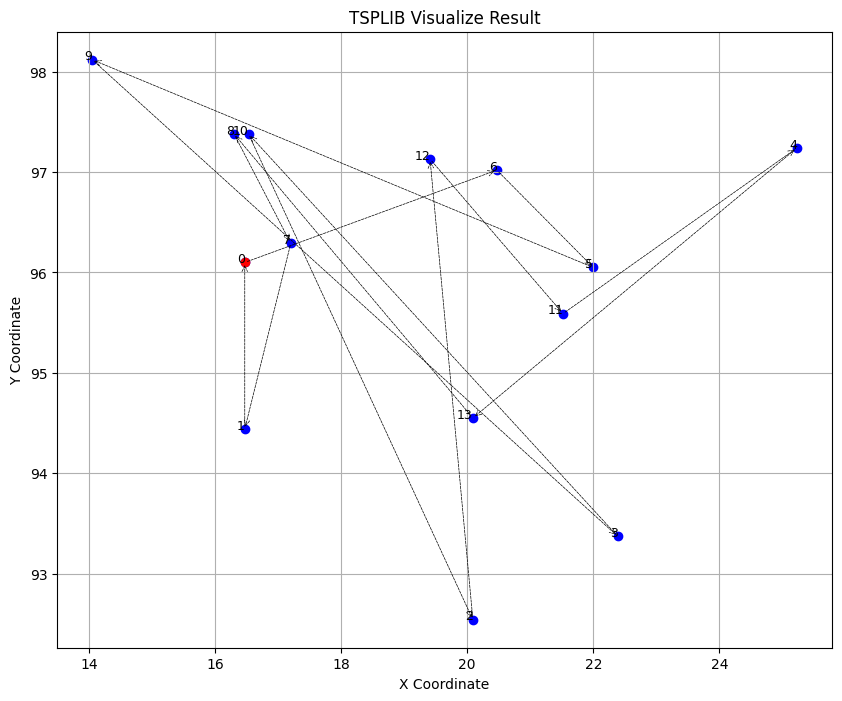

0 -> 6: 455
6 -> 5: 168
5 -> 9: 910
9 -> 3: 1070
3 -> 10: 768
10 -> 2: 618
2 -> 12: 455
12 -> 11: 275
11 -> 4: 418
4 -> 13: 636
13 -> 8: 498
8 -> 7: 154
7 -> 1: 197
1 -> 0: 153
obj value = 6775


In [9]:
# 実測値
visualize.plot_route()
visualize.to_objective_value()

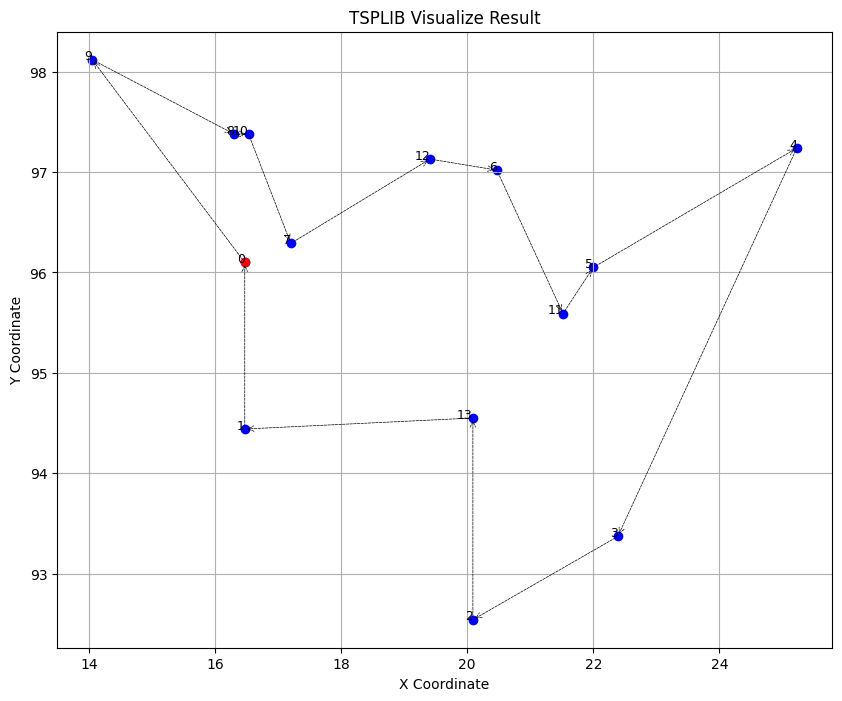

0 -> 9: 372
9 -> 8: 276
8 -> 10: 43
10 -> 7: 133
7 -> 12: 273
12 -> 6: 124
6 -> 11: 163
11 -> 5: 19
5 -> 4: 400
4 -> 3: 491
3 -> 2: 289
2 -> 13: 211
13 -> 1: 376
1 -> 0: 153
obj value = 3323


In [10]:
# 正解
visualize.plot_route(correct_ans_flg=True)
visualize.to_objective_value(correct_ans_flg=True)